# Convolutional Neural Networks

Here, we now upgrade our Image Perocessing, which we did prior with Sobel Operators, now with Convolutional Neural Networks of LeNet Architecture. 

## What is LeNet Architecture?
LeNet Architecture is basically where you repeatedly convolve, pool, and activate, an image, until you recognize what it is. It is less supervised than let's say the Sobel Operators that we did in Image Processing.

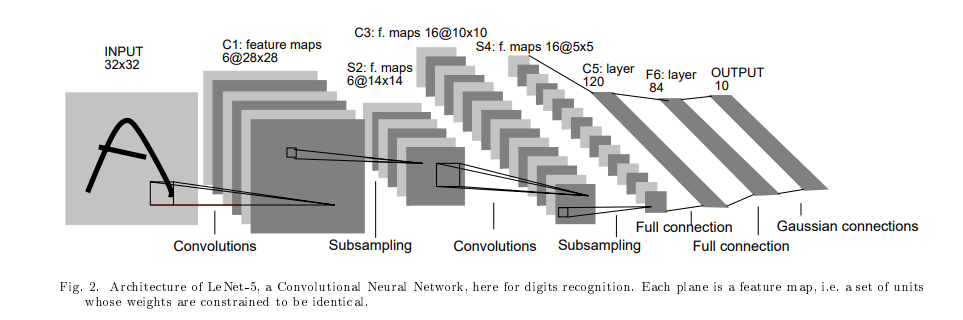

*Fig. 1. Sample architecture of a convolutional neural network*


We're using PyTorch yet again so we're gonna use our good GPU.

## Parameters
Let's import the dataset and set up the parameters on how we're going to train the data.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Hyperparameters

BATCH_SIZE = 64         # How many images the model looks at before updating the kernels
LEARNING_RATE = 0.01    # Sets how much the optimizer adjusts the weights
EPOCHS = 2 # More epochs = more passes over the data
MAX_BATCHES = 15         # For testing, interrupts training after MAX_BATCHES

# MNIST can be downloaded with torchvision.datasets
# ToTensor() scales pixels to [0, 1] and sets the shape to (Channels, Height, Width)
# root sets what folder the dataset is saved to
# download = True can be removed once downloaded
dataset_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
dataset_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# DataLoader uses our BATCH_SIZE hyperparameter to slice the 60,000 images
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=1000, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found

Failed download. Trying https -> http instead. Downloading http://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz to ./data/MNIST/raw/train-labels-idx1-ubyte.gz


100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Let's get the data

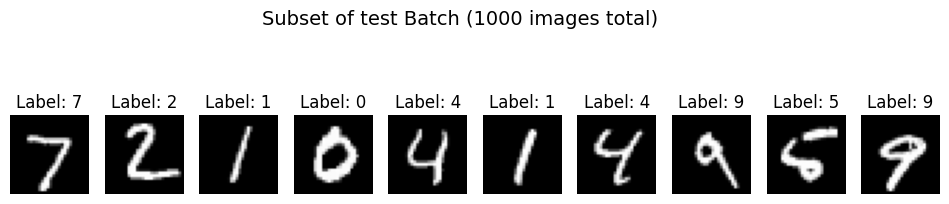

Batch shape: torch.Size([1000, 1, 28, 28])


In [2]:
# Get one batch of test_data
images, labels = next(iter(test_loader))


plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    
    # Squeeze data for plotting
    img = images[i].squeeze() 
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.suptitle("Subset of test Batch (1000 images total)", fontsize=14)
plt.show()

# Show the shape of the batch, you should expect [SIZE, channel, H, W]
print(f"Batch shape: {images.shape}") 

## How does the CNN Work?
Now, we do the CNN figure.

In [3]:
class SampleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 Input -> 6 filters (5x5 kernels)
        # Docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        self.conv1 = nn.Conv2d(1, 3, kernel_size=5)
        # Pooling of feature map image (24x24 -> 12x12). Stride defaults to kernel size
        # Docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(3, 6, kernel_size=5) # To make the next output 6x6, dim-kernel_size+1)
        
        
        # 3 filters * 12px * 12px = 432 input features for the linear "decision" layer
        self.fc1 = nn.Linear(3 *12 *12, 6 *8 *8)
        self.fc2 = nn.Linear(6*4*4, 10)

    def forward(self, x):
        # Forward pass: Conv -> activation (ReLu) -> pool -> flatten -> linear
        # Docs for ReLu:
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html
        f1 = torch.relu(self.conv1(x)) # Conv + Activation
        p1 = self.pool(f1)            # Pool feature map
        f2 = torch.relu(self.conv2(p1)) # Convolve the first pool again
        p2 = self.pool(f2)
        
        #Flatten vector: .view() flattens the 2D maps into a
        #1D Vector for the linear layer.
        v1 = p1.view(p1.size(0), -1) 
        v2 = p2.view(p2.size(0), -1)
        
        logits_raw = self.fc1(v1)            # Linear 864 -> 10
        logits_fin = self.fc2(v2)

        # For convenience, return all the intermediate outputs
        # as part of the return tuple. Make sure that only the
        # output from the logits is taken for computing the loss.
        return logits_raw, [(f1, p1)], v1, logits_fin, [(f2, p2)], v2

In [4]:
#Training our sample CNN
cnn_model = SampleCNN()
optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"Starting training: {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    cnn_model.train() # Enable training mode (weight updates allowed)
    
    for i, (imgs, lbls) in enumerate(train_loader):
        optimizer.zero_grad()               # Resets gradients
        _, _, _, logits, _, _ = cnn_model(imgs)      # Forward pass: Train on 64 images
        loss = criterion(logits, lbls)      # Calculate error using the set criterion function
        loss.backward()                     # Perform backpropagation
        optimizer.step()                    # Adjust the 5x5 weights

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Batch [{i}], Loss: {loss.item():.4f}")
            
        # If you only want to train on a set number of batches, 
        # you can interrupt the loop with this
        if i >= MAX_BATCHES:
            print(f"--> Reached MAX_BATCHES ({MAX_BATCHES}). Moving to next Epoch.")
            break

Starting training: 2 epochs...
Epoch [1/2], Batch [0], Loss: 2.3245
--> Reached MAX_BATCHES (15). Moving to next Epoch.
Epoch [2/2], Batch [0], Loss: 1.0660
--> Reached MAX_BATCHES (15). Moving to next Epoch.


In [5]:
cnn_model.eval()
with torch.no_grad():
    img, _ = dataset_test[0] #Test model for one of the dataset entries
    model_out = cnn_model(img.unsqueeze(0)) # Add batch dimension
    logit_out1, layer_out1, vec_out1, logit_out2, layer_out2, vec_out2 = model_out
    probs = torch.softmax(logit_out2, dim=1)          # Convert scores to probabilities

conv_out1, pool_out1 = layer_out1[0][0], layer_out1[0][1]
conv_out2, pool_out2 = layer_out2[0][0], layer_out2[0][1]

for name, param in cnn_model.named_parameters():
    print(f"{name} :: {param.detach().shape}")

conv1.weight :: torch.Size([3, 1, 5, 5])
conv1.bias :: torch.Size([3])
conv2.weight :: torch.Size([6, 3, 5, 5])
conv2.bias :: torch.Size([6])
fc1.weight :: torch.Size([384, 432])
fc1.bias :: torch.Size([384])
fc2.weight :: torch.Size([10, 96])
fc2.bias :: torch.Size([10])


Text(0.5, 1.0, 'Test data')

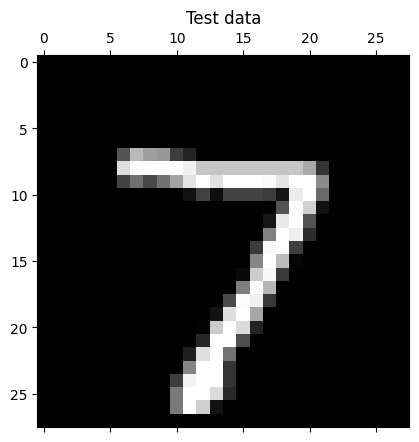

In [6]:
#Plot test image
plt.matshow(img[0], cmap = "gray")
plt.title("Test data")


## First Convolution Outputs


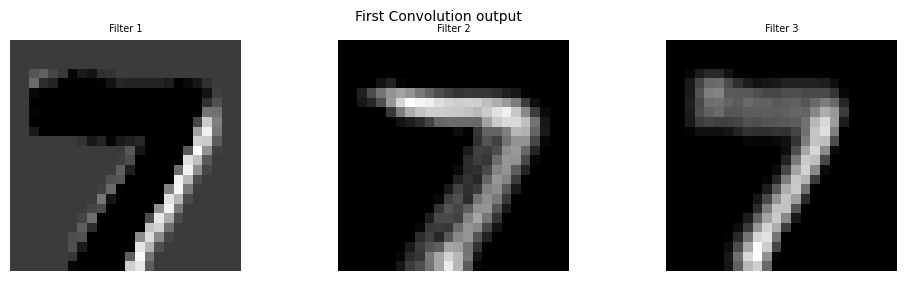

torch.Size([1, 3, 24, 24])


In [106]:
# Extract the 6 feature maps from the first batch item
# conv_out shape is [1, 3, 24, 24]
features = conv_out1[0].detach()
num_filters = conv_out1.shape[1]

fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
for i in range(num_filters):
    axes[i].imshow(features[i], cmap='gray') # 'magma' or 'viridis' shows activation intensity
    axes[i].set_title(f"Filter {i+1}", fontsize=7)
    axes[i].axis('off')

plt.suptitle("First Convolution output", fontsize=10)
plt.show()
print(conv_out1.shape)

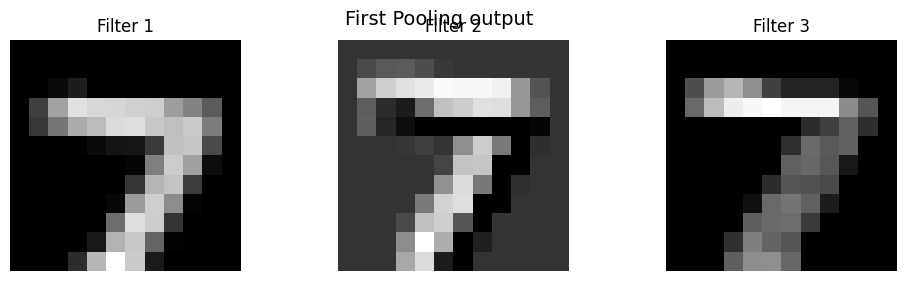

In [7]:
# Extract the 3 pooled feature maps
# conv_out shape is [1, 3, 12, 12]
features = pool_out1[0].detach()
num_filters = pool_out1.shape[1]

fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
for i in range(num_filters):
    axes[i].imshow(features[i], cmap='gray') # 'magma' or 'viridis' shows activation intensity
    axes[i].set_title(f"Filter {i+1}")
    axes[i].axis('off')

plt.suptitle("First Pooling output", fontsize=14)
plt.show()


## Second Convolution
Now, we do the second convolution layer in which we'll just feed on the pooled output of the first convolution.

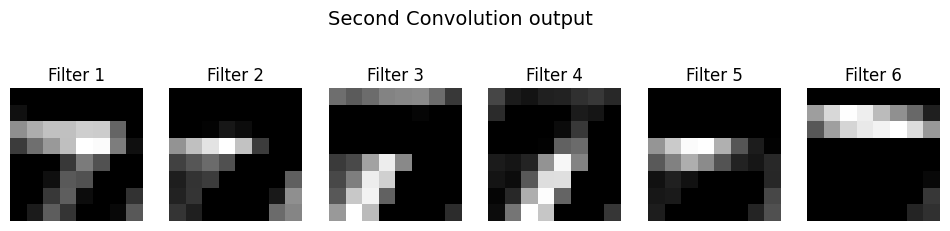

torch.Size([1, 6, 8, 8])


In [8]:
# Extract the 6 feature maps from the first batch item
# conv_out shape is [1, 6, 8, 8]
features = conv_out2[0].detach()
num_filters = conv_out2.shape[1]

fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
for i in range(num_filters):
    axes[i].imshow(features[i], cmap='gray') # 'magma' or 'viridis' shows activation intensity
    axes[i].set_title(f"Filter {i+1}")
    axes[i].axis('off')

plt.suptitle("Second Convolution output", fontsize=14)
plt.show()
print(conv_out2.shape)

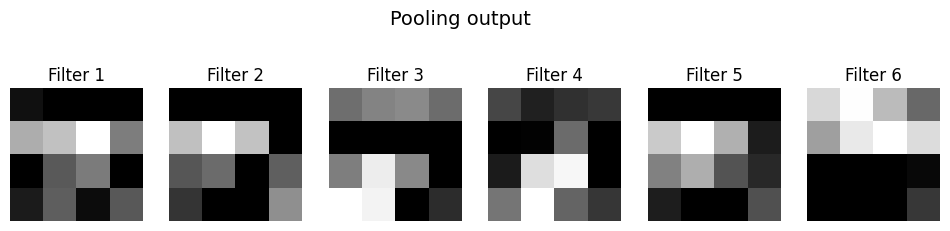

torch.Size([1, 6, 4, 4])


In [18]:
# Extract the 12 pooled feature maps
# conv_out shape is [1, 3, 12, 12]
features = pool_out2[0].detach()

num_filters = pool_out2.shape[1]

fig, axes = plt.subplots(1, num_filters, figsize=(12, 3))
for i in range(num_filters):
    axes[i].imshow(features[i], cmap='gray') # 'magma' or 'viridis' shows activation intensity
    axes[i].set_title(f"Filter {i+1}")
    axes[i].axis('off')

plt.suptitle("Pooling output", fontsize=14)
plt.show()
print(pool_out2.shape)

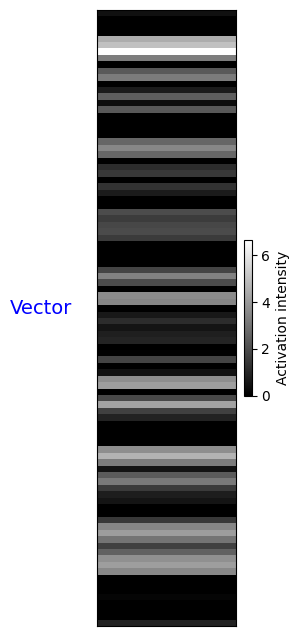

In [20]:
# Suppose vector is your flattened tensor of shape [96]
vector = features.view(-1).numpy()

# Reshape into a tall column (96 x 1)
matrix = vector.reshape(-1, 1)

fig, ax = plt.subplots(figsize=(2, 8))
im = ax.imshow(matrix, cmap='gray', aspect='auto')

# Add vertical label
ax.set_ylabel("Vector", fontsize=14, color="blue", rotation=0, labelpad=40)
ax.set_xticks([])
ax.set_yticks([])

plt.colorbar(im, ax=ax, fraction=0.05, pad=0.05, label="Activation intensity")
plt.show()


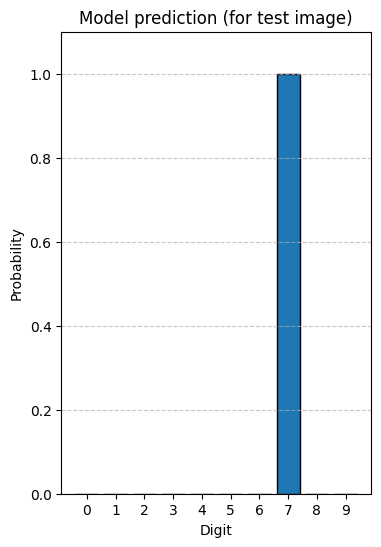

In [12]:
# Convert the tensor to a 1D numpy array so Matplotlib can read it
# We use .squeeze() to turn [1, 10] into just [10]
p_data = probs.detach().squeeze()

plt.figure(figsize=(4, 6))
plt.bar(range(10), p_data, edgecolor='black')

#Formatting for clarity
plt.xticks(range(10)) # Ensure 0-9 are labeled on the bottom
plt.ylim(0, 1.1)      # Set height to 100% (plus a little extra space)
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Model prediction (for test image)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

([], [])

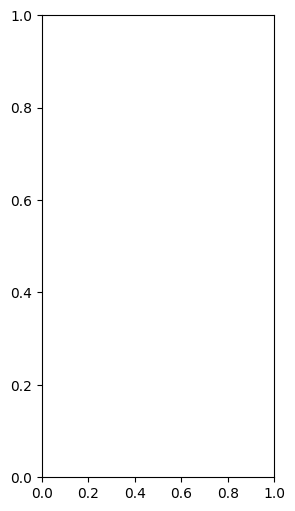

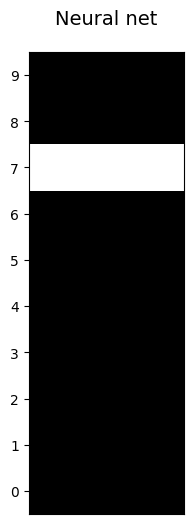

In [33]:
# Example probabilities tensor [1, 10]
p_data = probs.detach().squeeze()  # shape [10]

fig, ax = plt.subplots(figsize=(3, 6))
matrix = np.zeros((10, 1))  # 10 rows, 1 column


predicted = torch.argmax(p_data).item()


matrix[predicted] = 1      # make the predicted row white


# Formatting
# Highlight the predicted class (e.g., the max probability)
# Plot
plt.figure(figsize=(2, 6))
plt.imshow(matrix, cmap='gray', aspect='auto')
plt.yticks(range(10))
plt.gca().invert_yaxis()  # so 0 is at the top
plt.title("Neural net", fontsize=14, pad=20)
plt.xticks([])            # hide x-axis ticks


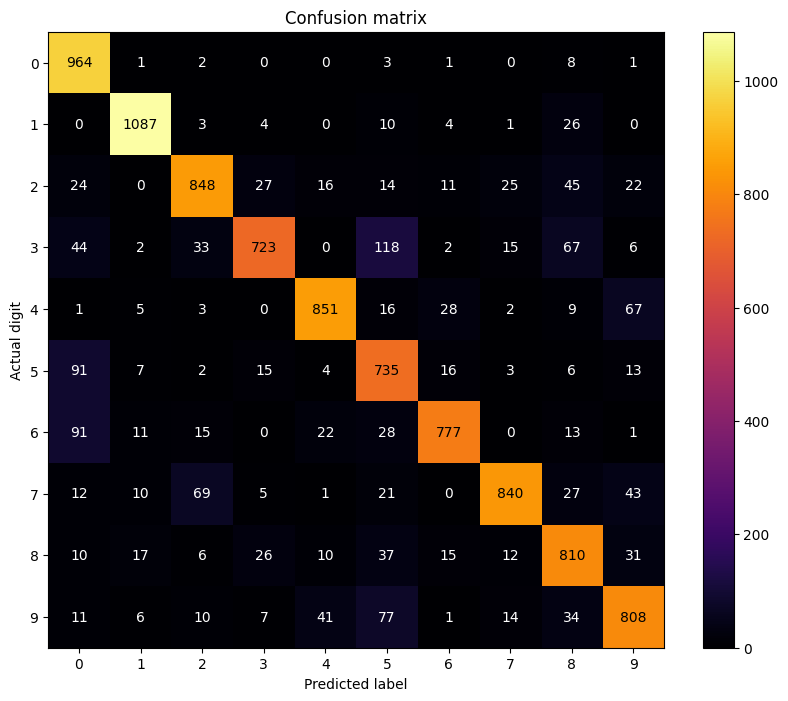

In [15]:
# Plotting confusion matrix
# Create the 10x10 grid (actual vs predicted)
matrix = torch.zeros(10, 10, dtype=torch.int32)

cnn_model.eval() # Always set to eval mode for testing!
with torch.no_grad():
    for imgs, lbls in test_loader:
        _, _, _, outputs, _, _ = cnn_model(imgs)
        preds = outputs.argmax(dim=1) 
        for t, p in zip(lbls, preds):
            matrix[t.item(), p.item()] += 1

# Plotting
plt.figure(figsize=(10, 8))
plt.imshow(matrix, cmap='inferno') # 'inferno' is great for spotting small errors
plt.colorbar()

# Add labels
classes = [str(i) for i in range(10)]
plt.xticks(range(10), classes)
plt.yticks(range(10), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actual digit")
plt.title("Confusion matrix")

# Optional: Draw the numbers inside the squares
for i in range(10):
    for j in range(10):
        plt.text(j, i, matrix[i, j].item(), ha="center", va="center", 
                 color="white" if matrix[i, j] < matrix.max()/2 else "black")
plt.savefig("Confusion.pdf")
plt.show()
